# 04. Deep Segment Analysis
Phân tích sâu các phân khúc thị trường: giá, sales, brand, engagement.
Mục tiêu: Tìm insights có ý nghĩa, không phân tích nông.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [10]:
df = pd.read_csv('../data/processed/combined_tiki_data.csv')
df['discount_pct'] = ((df['original_price'] - df['price']) / df['original_price'] * 100).round(2)
df['revenue_estimate'] = df['price'] * df['quantity_sold']
print(f"Dataset: {df.shape}")

Dataset: (41576, 21)


## 1. Price Segment Analysis

In [11]:
# Định nghĩa price segments (VND)
bins = [0, 100000, 300000, 500000, 1000000, float('inf')]
labels = ['0-100k', '100-300k', '300-500k', '500k-1M', '>1M']
df['price_segment'] = pd.cut(df['price'], bins=bins, labels=labels)

segment_analysis = df.groupby('price_segment').agg({
    'id': 'count',
    'price': 'mean',
    'quantity_sold': ['sum', 'mean'],
    'revenue_estimate': 'sum',
    'rating_average': 'mean',
    'review_count': 'mean',
    'discount_pct': 'mean'
}).round(2)

segment_analysis.columns = ['product_count', 'avg_price', 'total_sold', 'avg_sold_per_product', 
                             'total_revenue', 'avg_rating', 'avg_reviews', 'avg_discount']
segment_analysis['product_pct'] = (segment_analysis['product_count'] / len(df) * 100).round(1)
segment_analysis['revenue_pct'] = (segment_analysis['total_revenue'] / segment_analysis['total_revenue'].sum() * 100).round(1)

print("=== Price Segment Analysis ===")
print(segment_analysis)

=== Price Segment Analysis ===
               product_count   avg_price  total_sold  avg_sold_per_product  \
price_segment                                                                
0-100k                 23160    45725.41      536764                 23.18   
100-300k               10987   182717.46      145024                 13.20   
300-500k                2971   398472.12       31073                 10.46   
500k-1M                 2343   707713.76       18654                  7.96   
>1M                     2114  2561514.39        7576                  3.58   

               total_revenue  avg_rating  avg_reviews  avg_discount  \
price_segment                                                         
0-100k           24287547699        1.38         3.31          4.55   
100-300k         24916002704        1.47         3.34          7.18   
300-500k         12278335957        1.49         2.98          6.67   
500k-1M          12543122484        1.42         2.16          9.50

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20140\4268425662.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = df.groupby('price_segment').agg({


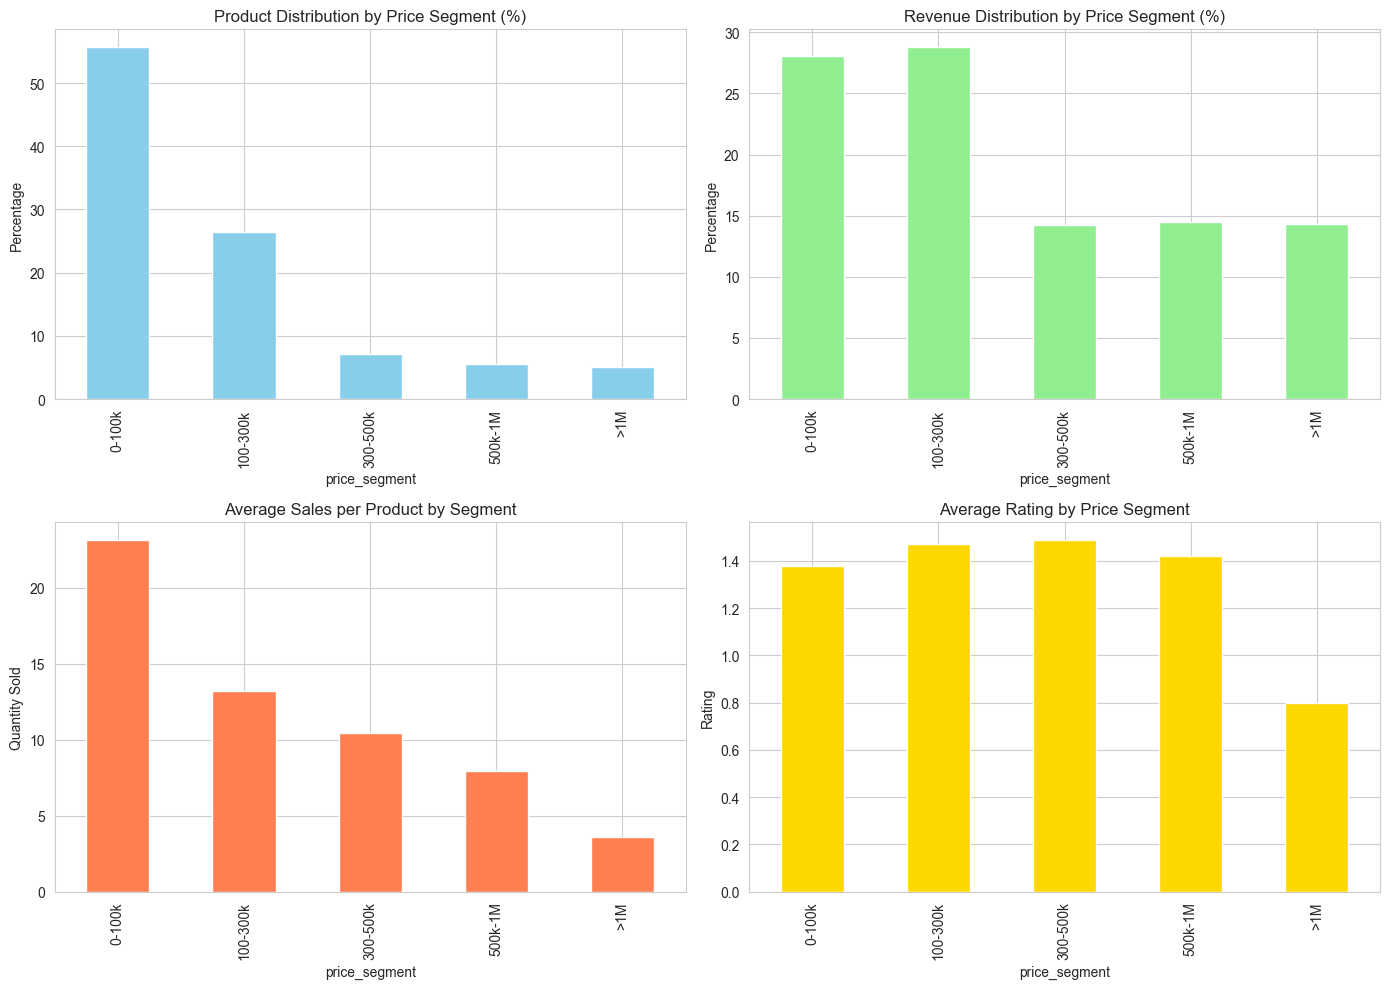

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

segment_analysis['product_pct'].plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Product Distribution by Price Segment (%)')
axes[0,0].set_ylabel('Percentage')

segment_analysis['revenue_pct'].plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Revenue Distribution by Price Segment (%)')
axes[0,1].set_ylabel('Percentage')

segment_analysis['avg_sold_per_product'].plot(kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Average Sales per Product by Segment')
axes[1,0].set_ylabel('Quantity Sold')

segment_analysis['avg_rating'].plot(kind='bar', ax=axes[1,1], color='gold')
axes[1,1].set_title('Average Rating by Price Segment')
axes[1,1].set_ylabel('Rating')

plt.tight_layout()
plt.show()

### Deep Dive: Dominant Price Segment

In [13]:
# Xác định segment chiếm ưu thế
dominant_segment = segment_analysis['product_count'].idxmax()
print(f"Dominant price segment: {dominant_segment}")
print(f"Contains {segment_analysis.loc[dominant_segment, 'product_count']} products ({segment_analysis.loc[dominant_segment, 'product_pct']}%)")
print(f"Generates {segment_analysis.loc[dominant_segment, 'revenue_pct']}% of total revenue")

# Phân tích chi tiết segment này
dominant_df = df[df['price_segment'] == dominant_segment]

print(f"\n=== {dominant_segment} Segment Details ===")
print(f"\nCategory breakdown:")
print(dominant_df['category'].value_counts())

print(f"\nTop 5 brands in this segment:")
print(dominant_df['brand'].value_counts().head())

print(f"\nTop 10 best sellers in this segment:")
top_in_segment = dominant_df.nlargest(10, 'quantity_sold')[['name', 'brand', 'price', 'quantity_sold', 'rating_average']]
print(top_in_segment)

Dominant price segment: 0-100k
Contains 23160 products (55.7%)
Generates 28.1% of total revenue

=== 0-100k Segment Details ===

Category breakdown:
category
fashion_accessories    12820
women_bags              2804
backpacks_suitcases     2357
women_shoes             2207
men_shoes               1855
men_bags                1117
Name: count, dtype: int64

Top 5 brands in this segment:
brand
OEM                              19361
Song An Eco                        500
\tOEM                              223
Hạnh Dương                         204
Trương Gia Túi Vải Túi Canvas      169
Name: count, dtype: int64

Top 10 best sellers in this segment:
                                                    name      brand  price  \
21530             Túi Đeo Chéo Unisex Laza TXTK349 (Đen)       LAZA  60000   
40621  Miếng lót giảm size cho giày bị rộng Cao Cấp -...     buybox  70000   
30526  Keo Dán Giày Nhiệt XIMO Trong Suốt Siêu Dính D...       Ximo  35000   
21528   Túi Đeo Chéo Unisex Haras 

## 2. Sales Performance Deep Dive

In [14]:
# Phân loại products theo sales performance
# quantity_sold có nhiều giá trị trùng nhau (đặc biệt 0), nên qcut(4) có thể lỗi biên trùng.
# Giảm số quantile khả dụng và drop duplicate edges để cell luôn chạy được.
base_labels = ['Low', 'Medium', 'High', 'Very High']
unique_sales = df['quantity_sold'].nunique(dropna=True)
q = min(4, unique_sales)

if q < 2:
    df['sales_quartile'] = pd.Categorical(['Low'] * len(df), categories=['Low'], ordered=True)
else:
    sales_bucket = pd.qcut(df['quantity_sold'], q=q, duplicates='drop')
    n_buckets = sales_bucket.cat.categories.size
    df['sales_quartile'] = sales_bucket.cat.rename_categories(base_labels[:n_buckets])

sales_performance = df.groupby('sales_quartile').agg({
    'id': 'count',
    'price': 'mean',
    'rating_average': 'mean',
    'review_count': 'mean',
    'discount_pct': 'mean',
    'number_of_images': 'mean',
    'quantity_sold': ['min', 'max', 'mean']
}).round(2)

print("=== Sales Performance Analysis ===")
print(sales_performance)

=== Sales Performance Analysis ===
                   id      price rating_average review_count discount_pct  \
                count       mean           mean         mean         mean   
sales_quartile                                                              
Low             31860  308606.75           0.59         0.19         4.71   
Medium           9716  153497.50           3.96        12.71         9.40   

               number_of_images quantity_sold                
                           mean           min    max   mean  
sales_quartile                                               
Low                        5.92             0      5   0.72  
Medium                     6.11             6  24847  73.72  


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20140\61106076.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_performance = df.groupby('sales_quartile').agg({


In [15]:
# So sánh best sellers vs poor sellers
top_10pct = df.nlargest(int(len(df)*0.1), 'quantity_sold')
bottom_10pct = df.nsmallest(int(len(df)*0.1), 'quantity_sold')

comparison = pd.DataFrame({
    'Top 10%': [
        top_10pct['price'].mean(),
        top_10pct['rating_average'].mean(),
        top_10pct['review_count'].mean(),
        top_10pct['discount_pct'].mean(),
        top_10pct['number_of_images'].mean(),
        (top_10pct['brand'] == 'OEM').mean() * 100
    ],
    'Bottom 10%': [
        bottom_10pct['price'].mean(),
        bottom_10pct['rating_average'].mean(),
        bottom_10pct['review_count'].mean(),
        bottom_10pct['discount_pct'].mean(),
        bottom_10pct['number_of_images'].mean(),
        (bottom_10pct['brand'] == 'OEM').mean() * 100
    ]
}, index=['Avg Price', 'Avg Rating', 'Avg Reviews', 'Avg Discount %', 'Avg Images', 'OEM %'])

comparison['Difference'] = comparison['Top 10%'] - comparison['Bottom 10%']
print("\n=== Top 10% vs Bottom 10% Sellers ===")
print(comparison.round(2))


=== Top 10% vs Bottom 10% Sellers ===
                  Top 10%  Bottom 10%  Difference
Avg Price       130083.76   348221.36  -218137.59
Avg Rating           4.36        0.02        4.34
Avg Reviews         25.93        0.01       25.93
Avg Discount %      11.41        2.70        8.70
Avg Images           6.21        5.68        0.53
OEM %               56.48       79.48      -23.00


## 3. Revenue Potential Analysis

Correlation between review_count and quantity_sold: 0.621


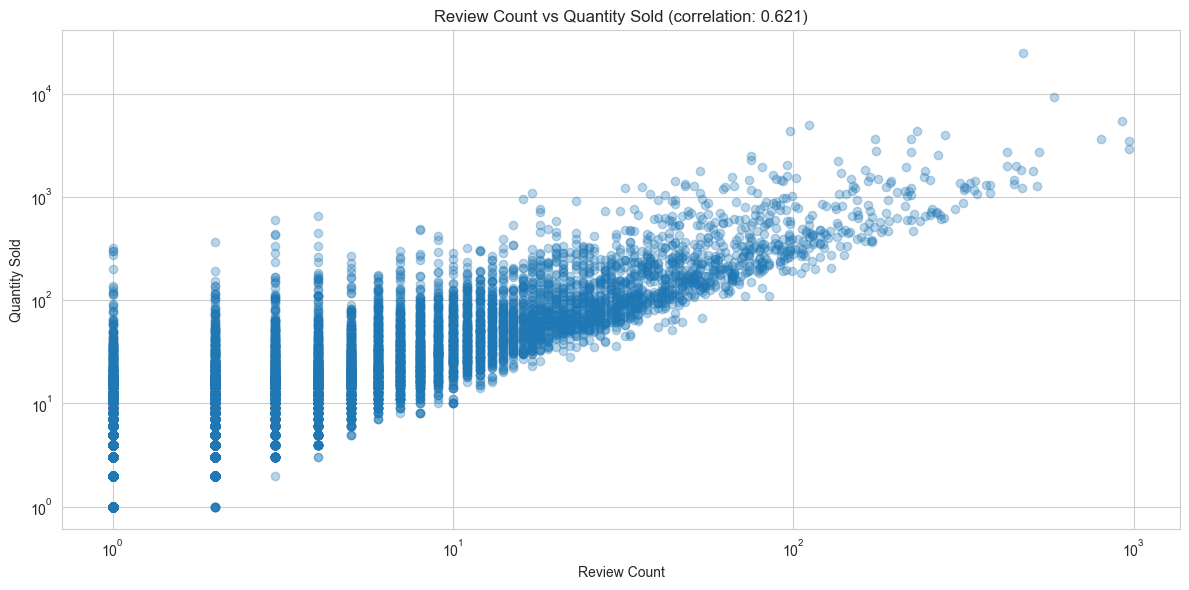

In [16]:
# Correlation: review_count vs quantity_sold
correlation = df['review_count'].corr(df['quantity_sold'])
print(f"Correlation between review_count and quantity_sold: {correlation:.3f}")

# Scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(df['review_count'], df['quantity_sold'], alpha=0.3)
plt.xlabel('Review Count')
plt.ylabel('Quantity Sold')
plt.title(f'Review Count vs Quantity Sold (correlation: {correlation:.3f})')
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.show()

In [17]:
# Phân tích products theo review count segments
df['review_segment'] = pd.cut(df['review_count'], 
                               bins=[0, 10, 50, 100, 500, float('inf')],
                               labels=['0-10', '10-50', '50-100', '100-500', '>500'])

review_impact = df.groupby('review_segment').agg({
    'id': 'count',
    'quantity_sold': 'mean',
    'rating_average': 'mean',
    'price': 'mean'
}).round(2)

review_impact.columns = ['product_count', 'avg_quantity_sold', 'avg_rating', 'avg_price']
print("\n=== Impact of Review Count on Sales ===")
print(review_impact)


=== Impact of Review Count on Sales ===
                product_count  avg_quantity_sold  avg_rating  avg_price
review_segment                                                         
0-10                    10576              15.39        4.38  211506.25
10-50                    1975             112.70        4.55  157117.93
50-100                    301             412.40        4.57  145321.32
100-500                   155            1089.00        4.57  162436.64
>500                        8            3812.38        4.65   88625.00


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20140\886635695.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_impact = df.groupby('review_segment').agg({


In [18]:
# High-revenue vs High-volume products
high_revenue = df.nlargest(100, 'revenue_estimate')
high_volume = df.nlargest(100, 'quantity_sold')

print(f"\nHigh-revenue products (top 100):")
print(f"  Avg price: {high_revenue['price'].mean():.0f} VND")
print(f"  Avg quantity sold: {high_revenue['quantity_sold'].mean():.0f}")
print(f"  Avg rating: {high_revenue['rating_average'].mean():.2f}")

print(f"\nHigh-volume products (top 100):")
print(f"  Avg price: {high_volume['price'].mean():.0f} VND")
print(f"  Avg quantity sold: {high_volume['quantity_sold'].mean():.0f}")
print(f"  Avg rating: {high_volume['rating_average'].mean():.2f}")


High-revenue products (top 100):
  Avg price: 476302 VND
  Avg quantity sold: 1519
  Avg rating: 4.55

High-volume products (top 100):
  Avg price: 86428 VND
  Avg quantity sold: 2013
  Avg rating: 4.49


## 4. Brand & Market Structure

In [19]:
# Top brands by revenue and market share
top_brands = df.groupby('brand').agg({
    'id': 'count',
    'revenue_estimate': 'sum',
    'quantity_sold': 'sum',
    'price': 'mean',
    'rating_average': 'mean'
}).sort_values('revenue_estimate', ascending=False).head(10)

top_brands.columns = ['product_count', 'total_revenue', 'total_sold', 'avg_price', 'avg_rating']
top_brands['market_share_pct'] = (top_brands['total_revenue'] / df['revenue_estimate'].sum() * 100).round(2)

print("\n=== Top 10 Brands by Revenue ===")
print(top_brands.round(2))


=== Top 10 Brands by Revenue ===
             product_count  total_revenue  total_sold   avg_price  avg_rating  \
brand                                                                           
OEM                  30673    27093879835      331603   151147.89        1.20   
HARAS                   54     3731737400       38183   137100.00        3.84   
Converse               186     2737586500        1674  1586897.85        1.04   
ANANSHOP688            197     2210186050        4550   551295.18        3.38   
BAMOZO                  29     1779086000        6046   430413.79        3.40   
LAZA                    10     1503167000       24895   253300.00        1.83   
buybox                  61     1472366410       25273    45422.72        4.07   
BIGGBEN                189     1422114000        4980   300455.03        3.62   
Sea Choice              14     1412941821         985  1199633.29        3.49   
Sakos                  122     1311375900        1888  1592022.54        2.

In [20]:
# OEM vs Branded products
oem_df = df[df['brand'] == 'OEM']
branded_df = df[df['brand'] != 'OEM']

brand_comparison = pd.DataFrame({
    'OEM': [
        len(oem_df),
        oem_df['price'].mean(),
        oem_df['quantity_sold'].mean(),
        oem_df['rating_average'].mean(),
        oem_df['review_count'].mean(),
        oem_df['revenue_estimate'].sum()
    ],
    'Branded': [
        len(branded_df),
        branded_df['price'].mean(),
        branded_df['quantity_sold'].mean(),
        branded_df['rating_average'].mean(),
        branded_df['review_count'].mean(),
        branded_df['revenue_estimate'].sum()
    ]
}, index=['Product Count', 'Avg Price', 'Avg Quantity Sold', 'Avg Rating', 'Avg Reviews', 'Total Revenue'])

print("=== OEM vs Branded Products ===")
print(brand_comparison.round(2))

=== OEM vs Branded Products ===
                            OEM       Branded
Product Count      3.067300e+04  1.090300e+04
Avg Price          1.511479e+05  6.133572e+05
Avg Quantity Sold  1.081000e+01  3.737000e+01
Avg Rating         1.200000e+00  1.900000e+00
Avg Reviews        1.880000e+00  6.580000e+00
Total Revenue      2.709388e+10  5.930383e+10


## 5. Customer Engagement Patterns

In [21]:
# High engagement but low sales (opportunity products)
df['engagement_score'] = df['review_count'] + df['favourite_count']
high_engagement = df[df['engagement_score'] > df['engagement_score'].quantile(0.75)]
low_sales = df[df['quantity_sold'] < df['quantity_sold'].quantile(0.5)]

opportunity_products = high_engagement[high_engagement['id'].isin(low_sales['id'])]

print(f"=== Opportunity Products (High Engagement, Low Sales) ===")
print(f"Found {len(opportunity_products)} products")
print(f"\nTop 10 opportunity products:")
print(opportunity_products.nlargest(10, 'engagement_score')[['name', 'brand', 'price', 'engagement_score', 'quantity_sold', 'rating_average']])

=== Opportunity Products (High Engagement, Low Sales) ===
Found 0 products

Top 10 opportunity products:
Empty DataFrame
Columns: [name, brand, price, engagement_score, quantity_sold, rating_average]
Index: []


In [22]:
# High sales but low engagement (commodity products)
high_sales = df[df['quantity_sold'] > df['quantity_sold'].quantile(0.75)]
low_engagement = df[df['engagement_score'] < df['engagement_score'].quantile(0.5)]

commodity_products = high_sales[high_sales['id'].isin(low_engagement['id'])]

print(f"\n=== Commodity Products (High Sales, Low Engagement) ===")
print(f"Found {len(commodity_products)} products")
print(f"\nTop 10 commodity products:")
print(commodity_products.nlargest(10, 'quantity_sold')[['name', 'brand', 'price', 'quantity_sold', 'engagement_score', 'rating_average']])


=== Commodity Products (High Sales, Low Engagement) ===
Found 0 products

Top 10 commodity products:
Empty DataFrame
Columns: [name, brand, price, quantity_sold, engagement_score, rating_average]
Index: []


## 6. Key Insights Summary

In [23]:
insights = []

# Insight 1: Price segment dominance
dominant_seg = segment_analysis['product_count'].idxmax()
insights.append(f"1. Price Segment: {dominant_seg} segment dominates with {segment_analysis.loc[dominant_seg, 'product_pct']}% of products but only {segment_analysis.loc[dominant_seg, 'revenue_pct']}% of revenue")

# Insight 2: Review-sales correlation
corr = df['review_count'].corr(df['quantity_sold'])
insights.append(f"2. Review Impact: Strong correlation ({corr:.3f}) between review count and sales - products with 50+ reviews sell {review_impact.loc['50-100', 'avg_quantity_sold'] / review_impact.loc['0-10', 'avg_quantity_sold']:.1f}x more")

# Insight 3: OEM vs Branded
oem_pct = len(oem_df) / len(df) * 100
insights.append(f"3. Brand Structure: OEM products are {oem_pct:.1f}% of catalog but branded products have {branded_df['price'].mean() / oem_df['price'].mean():.1f}x higher avg price")

# Insight 4: Top performers
top_10_revenue_share = (high_revenue['revenue_estimate'].sum() / df['revenue_estimate'].sum() * 100)
insights.append(f"4. Revenue Concentration: Top 100 products generate {top_10_revenue_share:.1f}% of total revenue")

# Insight 5: Opportunities
insights.append(f"5. Market Opportunities: {len(opportunity_products)} products show high engagement but low sales - potential for optimization")

print("=== KEY INSIGHTS ===")
for insight in insights:
    print(f"\n{insight}")

=== KEY INSIGHTS ===

1. Price Segment: 0-100k segment dominates with 55.7% of products but only 28.1% of revenue

2. Review Impact: Strong correlation (0.621) between review count and sales - products with 50+ reviews sell 26.8x more

3. Brand Structure: OEM products are 73.8% of catalog but branded products have 4.1x higher avg price

4. Revenue Concentration: Top 100 products generate 31.8% of total revenue

5. Market Opportunities: 0 products show high engagement but low sales - potential for optimization
